# User distribution by Subscription status

C:\Users\SajayN\AppData\Local\Temp\ipykernel_18996\4125333264.py:26: SAWarning: Unrecognized server version info '17.0.1115.1'.  Some SQL Server features may not function properly.
  with engine.connect() as con:


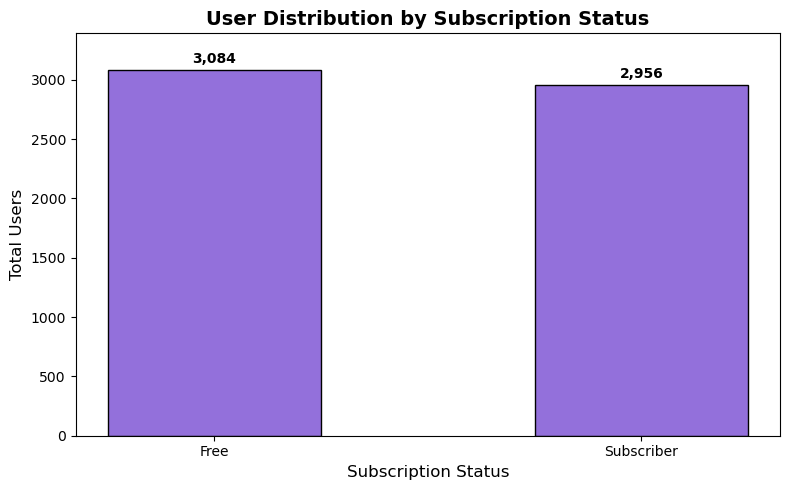

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

# 1. Setup your database engine
connection_string = (
    "mssql+pyodbc://@./DA07_movieDB?"
    "driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)
engine = create_engine(connection_string)

# 2. SQL Query to get subscription counts sorted from highest to lowest
query = """
SELECT 
    subscription_status,
    COUNT(user_id) AS total_users
FROM [dbo].[users]
GROUP BY 
    subscription_status
ORDER BY 
    total_users DESC; -- Puts the most popular subscription tier first
"""

try:
    # 3. Pull the query output into your data frame
    with engine.connect() as con:
        df_subscription = pd.read_sql(query, con)
    
    # 4. Initialize the plot window
    plt.figure(figsize=(8, 5))
    
    # 5. Build the vertical bar chart
    bars = plt.bar(
        df_subscription['subscription_status'], 
        df_subscription['total_users'], 
        color='mediumpurple', 
        edgecolor='black',
        width=0.5
    )
    
    # 6. Inject the exact user numbers on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2, 
            height + (max(df_subscription['total_users']) * 0.01), 
            f'{int(height):,}', 
            va='bottom', 
            ha='center', 
            fontweight='bold',
            fontsize=10
        )
    
    # 7. Customize the chart layout
    plt.xlabel('Subscription Status', fontsize=12)
    plt.ylabel('Total Users', fontsize=12)
    plt.title('User Distribution by Subscription Status', fontsize=14, fontweight='bold')
    
    # Add whitespace padding to the top of the y-axis
    plt.ylim(0, max(df_subscription['total_users']) * 1.1)
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

C:\Users\SajayN\AppData\Local\Temp\ipykernel_56216\1024436083.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con)


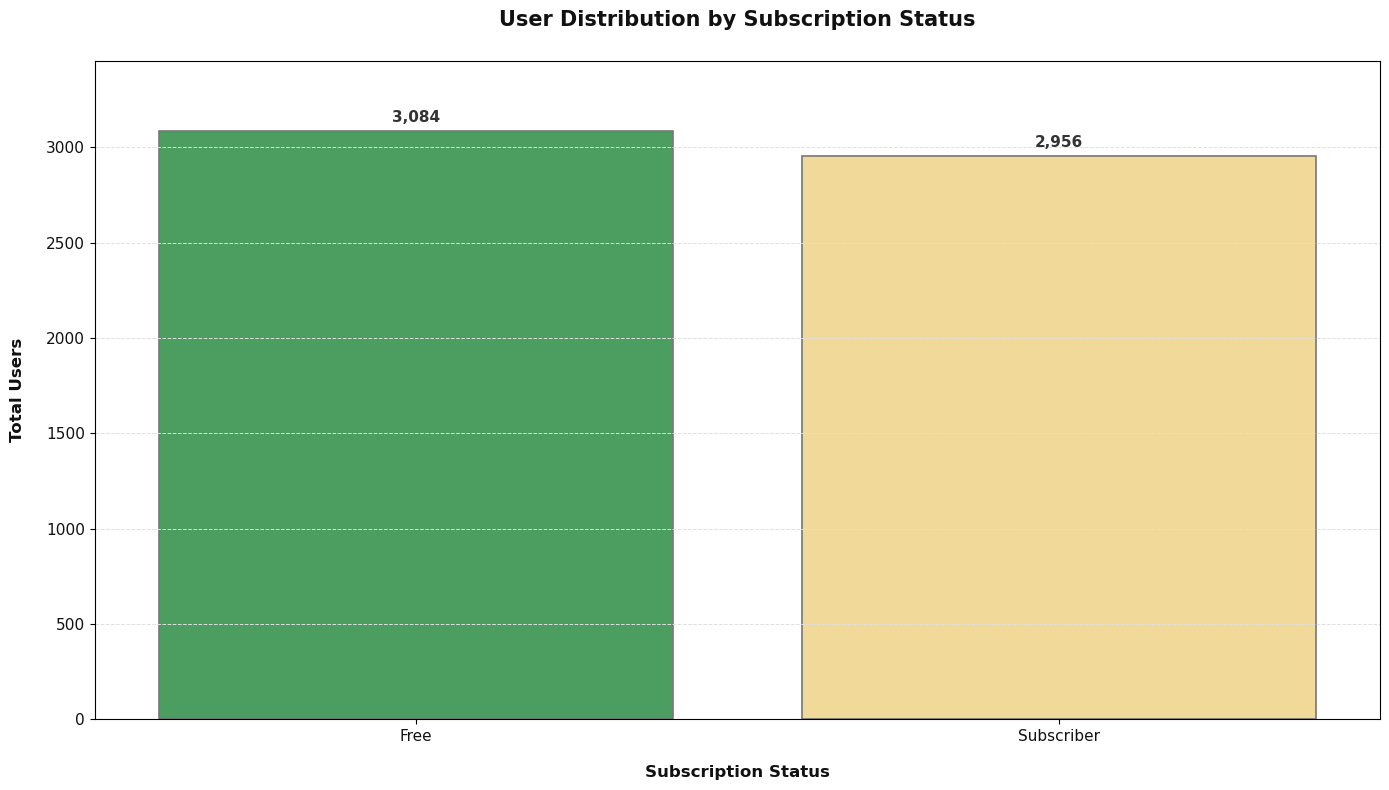

In [2]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
import matplotlib.colors as mcolors

# 1. Connect to your SQL Server
con = pyodbc.connect(
    DRIVER='{ODBC Driver 17 for SQL Server}', 
    SERVER='.', 
    DATABASE='DA07_movieDB', 
    Trusted_Connection='Yes', 
    autocommit=True
)

# 2. SQL Query: Fetching user distribution by subscription status
query = """
SELECT 
    subscription_status,
    COUNT(user_id) AS total_users
FROM [dbo].[Users]
GROUP BY 
    subscription_status
ORDER BY 
    total_users DESC;
"""

df = pd.read_sql(query, con)
con.close()

# 3. Create a custom Gradient: Green for highest, Saffron/Orange for lowest
if not df.empty:
    min_users = df['total_users'].min()
    max_users = df['total_users'].max()
    
    if max_users == min_users:
        norm_vals = [0.7] * len(df)
    else:
        # Normalize data values between 0.4 (Saffron-Orange) and 0.85 (Deep Green) 
        # using the reversed Red-Yellow-Green colormap
        norm_vals = 0.4 + 0.45 * (df['total_users'] - min_users) / (max_users - min_users)
    
    colormap = cm.RdYlGn
    bar_colors = [mcolors.to_hex(colormap(val)) for val in norm_vals]
else:
    bar_colors = []

# 4. Setup the Interface Canvas with a White Background
plt.figure(figsize=(14, 8), facecolor='#FFFFFF') 
ax = plt.gca()
ax.set_facecolor('#FFFFFF')

# Create the VERTICAL bar plot using our green-to-saffron gradient
sns.barplot(
    x='subscription_status', 
    y='total_users', 
    data=df, 
    palette=bar_colors,
    hue='subscription_status',
    legend=False,
    edgecolor='#777777',  # Soft clean border
    linewidth=1.2
)

# 5. Clean Dashboard Styling
plt.title('User Distribution by Subscription Status', 
          fontsize=15, fontweight='bold', color='#111111', pad=25)

plt.xlabel('Subscription Status', fontsize=12, fontweight='bold', color='#111111', labelpad=15)
plt.ylabel('Total Users', fontsize=12, fontweight='bold', color='#111111', labelpad=15)

# Style tick marks
plt.xticks(color='#111111', fontsize=11)
plt.yticks(color='#111111', fontsize=11)
plt.grid(color='#E0E0E0', linestyle='--', linewidth=0.7, axis='y') 

# Dynamically adjust Y-axis ceiling limit for spacing
if not df.empty:
    plt.ylim(0, df['total_users'].max() * 1.12) 

# 6. Clean Vertical Bar Data Labels
for i, p in enumerate(ax.patches):
    height = p.get_height()
    user_count = int(df.iloc[i]['total_users'])
    
    label_text = f"{user_count:,}"
    
    ax.text(
        p.get_x() + p.get_width() / 2, 
        height + (df['total_users'].max() * 0.01), 
        label_text, 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold',
        color='#333333'
    )

# Optimize layout constraints
plt.tight_layout()
plt.show()